In [1]:
from QLBM import QLBM, collision, InitializeQC
from QLBM_1 import QLBM1, collision1, InitializeQC1
from QLBM_2 import QLBM2, collision2, InitializeQC2
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 16, 16
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 26000
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [3]:
Q = 9
Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
dx = dy = 1.0
dt = dx
c = dt/dx
Re = 100

f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))
f_qeq = np.zeros((Nx+1, Ny+1, Q))
fq = np.zeros((Nx+1, Ny+1, Q))

Lx = dx * float(Nx)
Ly = dy * float(Ny)
U = 0.1
cs = np.sqrt(c**2/3)
nu = U * Lx / Re
nu_star = dt/6

tau_f = 1.0
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
rhoq = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
uq = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])

u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
u_t = np.zeros((Nx+3, Ny+3))
v_t = np.zeros((Nx+3, Ny+3))
u_qt = np.zeros((Nx+3, Ny+3))
v_qt = np.zeros((Nx+3, Ny+3))

rho[:, :] = rho_0
u[:, Ny, 0] = U
print(Nx+1,Re)
q_error = []
c_error = []
qc_error = []

16 100


In [4]:
##Initial
rho[:, :] = rho_0
u[:, Ny, 0] = U

In [5]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator1 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator2 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [6]:
def possion_f(u_hat,v_hat,delta_x):
    vor_u = vor_v = np.zeros_like(u_hat)
    i_coords, j_coords = np.indices(u_hat.shape)

    i1 = np.where(i_coords == 0, 0, 
              np.where(i_coords == u_hat.shape[0]-1, i_coords, i_coords + 1))
    i2 = np.where(i_coords == 0, 1, 
              np.where(i_coords == u_hat.shape[0]-1, i_coords - 1, i_coords))
    i3 = np.where(i_coords == 0, 2, 
              np.where(i_coords == u_hat.shape[0]-1, i_coords - 2, i_coords - 1))

    j1 = np.where(j_coords == 0, 0, 
              np.where(j_coords == u_hat.shape[0]-1, j_coords, j_coords + 1))
    j2 = np.where(j_coords == 0, 1, 
              np.where(j_coords == u_hat.shape[0]-1, j_coords - 1, j_coords))
    j3 = np.where(j_coords == 0, 2, 
              np.where(j_coords == u_hat.shape[0]-1, j_coords - 2, j_coords - 1))

    diff_i_u = u_hat[i1, j_coords] - 2.0 * u_hat[i2, j_coords] + u_hat[i3, j_coords]
    diff_j_u = u_hat[i_coords, j1] - 2.0 * u_hat[i_coords, j2] + u_hat[i_coords, j3]
    vor_u = (diff_i_u + diff_j_u) / delta_x**2

    diff_i_v = v_hat[i1, j_coords] - 2.0 * v_hat[i2, j_coords] + v_hat[i3, j_coords]
    diff_j_v = v_hat[i_coords, j1] - 2.0 * v_hat[i_coords, j2] + v_hat[i_coords, j3]
    vor_v = (diff_i_v + diff_j_v) / delta_x**2

    return vor_u, vor_v

In [7]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity

# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    
    u_d, v_d= possion_f(u[:,:,0],u[:,:,1],dx)
    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp)

    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    ##streaming
    #f[:, :, 0] = f[:, :, 0]
    f[1:Nx+1, :, 1] = f[0:Nx, :, 1]
    f[:, 1:Ny+1, 2] = f[:, 0:Ny, 2]
    f[0:Nx, :, 3] = f[1:Nx+1, :, 3]
    f[:, 0:Ny, 4] = f[:, 1:Ny+1, 4]
    f[1:Nx+1, 1:Ny+1, 5] = f[0:Nx, 0:Ny, 5]
    f[0:Nx, 1:Ny+1, 6] = f[1:Nx+1, 0:Ny, 6]
    f[0:Nx, 0:Ny, 7] = f[1:Nx+1, 1:Ny+1, 7]
    f[1:Nx+1, 0:Ny, 8] = f[0:Nx, 1:Ny+1, 8]
    
    rho = f[:, :, 0] + f[:, :, 1] +f[:, :, 2]+f[:, :, 3]+f[:, :, 4]+f[:, :, 5]+f[:, :, 6]+f[:, :, 7]+f[:, :, 8]
    rho[:, 0] = rho[:,1]#4.0*rho[:,1] - 6.0*rho[:,2] + 4.0*rho[:,3] - rho[:,4]
    rho[0, :] = rho[1, :]#4.0*rho[1, :] - 6.0*rho[2, :] + 4.0*rho[3, :] - rho[4, :]
    rho[Ny, :] = rho[Ny-1, :]#4.0*rho[Ny-1, :] - 6.0*rho[Ny-2, :] + 4.0*rho[Ny-3, :] - rho[Ny-4, :]
    rho[:, Ny] = rho[:,Ny-1]#4.0*rho[:,Ny-1] - 6.0*rho[:,Ny-2] + 4.0*rho[:,Ny-3] - rho[:,Ny-4]
    u[:, :, 0] = (f[:, :, 1] - f[:, :, 3] + f[:, :, 5] - f[:, :, 6] - f[:, :, 7] + f[:, :, 8]) / rho
    u[:, :, 1] = (f[:, :, 2] - f[:, :, 4] + f[:, :, 5] + f[:, :, 6] - f[:, :, 7] - f[:, :, 8]) / rho
    u[:, :, 0] = u[:, :, 0] + dt*(nu-nu_star)*u_d
    u[:, :, 1] = u[:, :, 1] + dt*(nu-nu_star)*v_d
    u[:, 0, 0] = u[0, :, 0] = u[Ny, :, 0] = 0.0
    u[:, Ny, 0] = U
    u[:, 0, 1] = u[0, :, 1] = u[Ny, :, 1] = u[:, Ny, 1] = 0.0
    
    # Create and run the quantum circuit for LBM, rho
    u_pd, v_pd= possion_f(Psi_qlbm1[t,:,:],Psi_qlbm2[t,:,:],dx)
    qc = QLBM(density_field=Psi_qlbm[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector = np.array(result.get_statevector())
    real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm[t + 1, :, :] = real_part_statevector_reshaped * np.linalg.norm(Psi_qlbm[t, :, :].flatten()) * 4
    Psi_qlbm[t + 1,:, 0] = Psi_qlbm[t + 1,:,1]#4.0*Psi_qlbm[t + 1,:,1] - 6.0*Psi_qlbm[t + 1,:,2] + 4.0*Psi_qlbm[t + 1,:,3] - Psi_qlbm[t + 1,:,4]
    Psi_qlbm[t + 1,0, :] = Psi_qlbm[t + 1,1, :]#4.0*Psi_qlbm[t + 1,1, :] - 6.0*Psi_qlbm[t + 1,2, :] + 4.0*Psi_qlbm[t + 1,3, :] - Psi_qlbm[t + 1,4, :]
    Psi_qlbm[t + 1,Ny, :] = Psi_qlbm[t + 1,Ny-1, :]#4.0*Psi_qlbm[t + 1,Ny-1, :] - 6.0*Psi_qlbm[t + 1,Ny-2, :] + 4.0*Psi_qlbm[t + 1,Ny-3, :] - Psi_qlbm[t + 1,Ny-4, :]
    Psi_qlbm[t + 1,:, Ny] = Psi_qlbm[t + 1,:,Ny-1]#4.0*Psi_qlbm[t + 1,:,Ny-1] - 6.0*Psi_qlbm[t + 1,:,Ny-2] + 4.0*Psi_qlbm[t + 1,:,Ny-3] - Psi_qlbm[t + 1,:,Ny-4]
    
    # Create and run the quantum circuit for LBM, u
    qc1 = QLBM1(density_field=Psi_qlbm0, velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit1 = transpile(qc1, simulator1)
    result1 = simulator1.run(compiled_circuit1).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector1 = np.array(result1.get_statevector())
    real_part_statevector1 = np.real(statevector1[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped1 = np.reshape(real_part_statevector1, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm1[t + 1, :, :] = real_part_statevector_reshaped1 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    Psi_qlbm1[t + 1,:, 0] = uq[:,0,0]
    Psi_qlbm1[t + 1,0, :] = uq[0,:,0]
    Psi_qlbm1[t + 1,Ny, :] = uq[Ny,:,0]
    Psi_qlbm1[t + 1,:, Ny] = uq[:,Ny,0]

    # Create and run the quantum circuit for LBM, u
    qc2 = QLBM2(density_field=Psi_qlbm0, velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit2 = transpile(qc2, simulator2)
    result2 = simulator2.run(compiled_circuit2).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector2 = np.array(result2.get_statevector())
    real_part_statevector2 = np.real(statevector2[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped2 = np.reshape(real_part_statevector2, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm2[t + 1, :, :] = real_part_statevector_reshaped2 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    Psi_qlbm2[t + 1,:, 0] = uq[:,0,1]
    Psi_qlbm2[t + 1,0, :] = uq[0,:,1]
    Psi_qlbm2[t + 1,Ny, :] = uq[Ny,:,1]
    Psi_qlbm2[t + 1,:, Ny] = uq[:,Ny,1]

    Psi_qlbm1[t + 1,:, :] = Psi_qlbm1[t + 1,:, :] + dt*(nu-nu_star)*u_pd
    Psi_qlbm2[t + 1,:, :] = Psi_qlbm2[t + 1,:, :] + dt*(nu-nu_star)*v_pd

    Psi_qlbm1[t + 1,:, 0] = Psi_qlbm1[t + 1,0, :] = Psi_qlbm1[t + 1,Ny, :] = 0.0
    Psi_qlbm1[t + 1,:, Ny] = U
    Psi_qlbm2[t + 1,:, 0] = Psi_qlbm2[t + 1,0, :] = Psi_qlbm2[t + 1,Ny, :] = Psi_qlbm2[t + 1,:, Ny] = 0.0
    
    rhoq = Psi_qlbm[t + 1, :, :].copy()
    uq[:,:,0] = Psi_qlbm1[t + 1, :, :].copy()
    uq[:,:,1] = Psi_qlbm2[t + 1, :, :].copy()
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()
    
    error = np.sum(np.sqrt((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2))/np.sum(np.sqrt(u[:, :, 0]**2+u[:, :, 1]**2))
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()
    
    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2))/np.sum(np.sqrt(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2))
    error2 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2))/np.sum(np.sqrt(u_n**2+v_n**2))
    
    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error1 < 1e-6:
        break
    print(t, error, error1, error2)

0 1.0 0.012954966070348597 2.3045763305113636e-14
1 0.012439447312400759 0.012439427065498733 1.048537667331549e-05
2 0.011933570143133109 0.011933353983743214 3.168075253529592e-05
3 0.011564650977023984 0.011564202108821487 6.306364469310163e-05
4 0.011382645037866575 0.011381920635566863 0.00010383670989500652
5 0.011391541539101255 0.011390487439915662 0.00015340248385705888
6 0.011544898982351507 0.011543778767901585 0.0002113589249550541
7 0.011843781284421208 0.011841843392361055 0.0002772520812242776
8 0.01221879500501847 0.012216806667459263 0.00035026433395117084
9 0.012673535249911197 0.0126708902089074 0.00042845332826737164
10 0.013175258046529189 0.013172005241091491 0.0005087464517050069
11 0.013698698130391092 0.013695620758439941 0.0005876364749101579
12 0.014250844504267004 0.01424753580685368 0.0006623647345357238
13 0.014873995220140553 0.01487084940822675 0.000731987695485138
14 0.015492855916413313 0.015489386766520376 0.0007979732751158868
15 0.016052218755614123

In [ ]:
np.savetxt("Re=100_64\QLBM_u_Re_100_"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Re=100_64\QLBM_v_Re_100_"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Re=100_64\QLBM_rho_Re_100_"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Re=100_64\CLBM_u_Re_100_"+str(t)+".csv",u[:,:,0],delimiter=",")
np.savetxt("Re=100_64\CLBM_v_Re_100_"+str(t)+".csv",u[:,:,1],delimiter=",")
np.savetxt("Re=100_64\CLBM_rho_Re_100_"+str(t)+".csv",rho,delimiter=",")
np.savetxt("Re=100_64\QLBM_error.csv",q_error,delimiter=",")
np.savetxt("Re=100_64\CLBM_error.csv",c_error,delimiter=",")
np.savetxt("Re=100_64\QLBM_CLBM_error.csv",qc_error,delimiter=",")

In [8]:
print(t, error, error1, error2)

2150 1.0212393937816216e-06 9.990470244808888e-07 0.001505849344840561


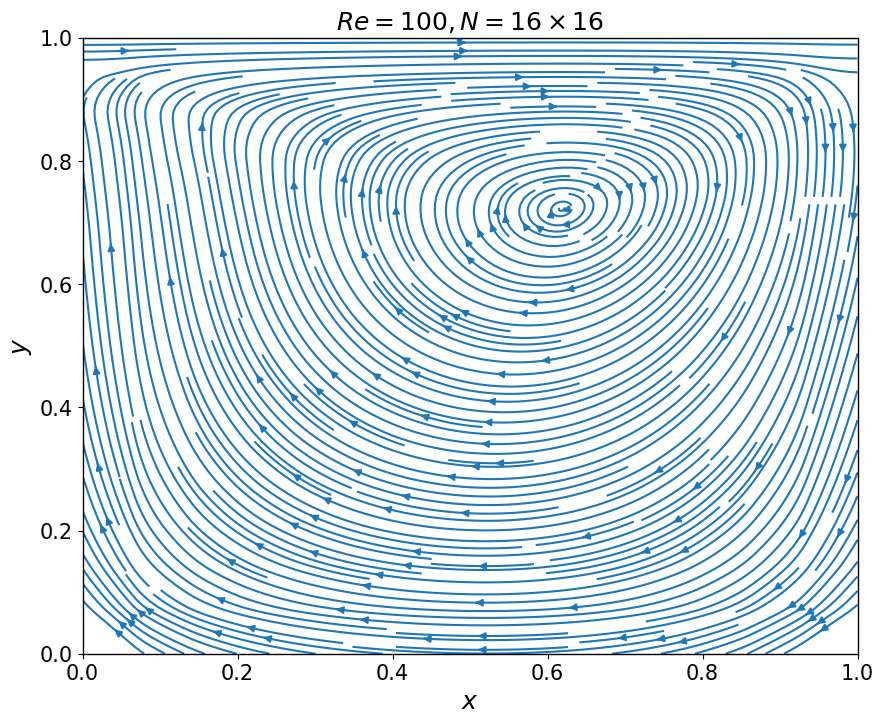

In [9]:
x = np.linspace(0,1,Nx+1)[:,None]
y = np.linspace(0,1,Ny+1)[:,None]
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(10, 8))
plt.streamplot(X,Y,u[:,:,0].T,u[:,:,1].T,density=3)
plt.tick_params(labelsize=15)
plt.xlim(0.0,1.0)
plt.xlabel('$x$', size = 18)
plt.ylabel('$y$', size = 18)
plt.title(r"$Re=100,N = 16 \times 16$", size = 18)
plt.ylim(0.0,1.0)
fig1=plt.gcf()
ax=plt.gca();
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
#plt.savefig('streamline_classical.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

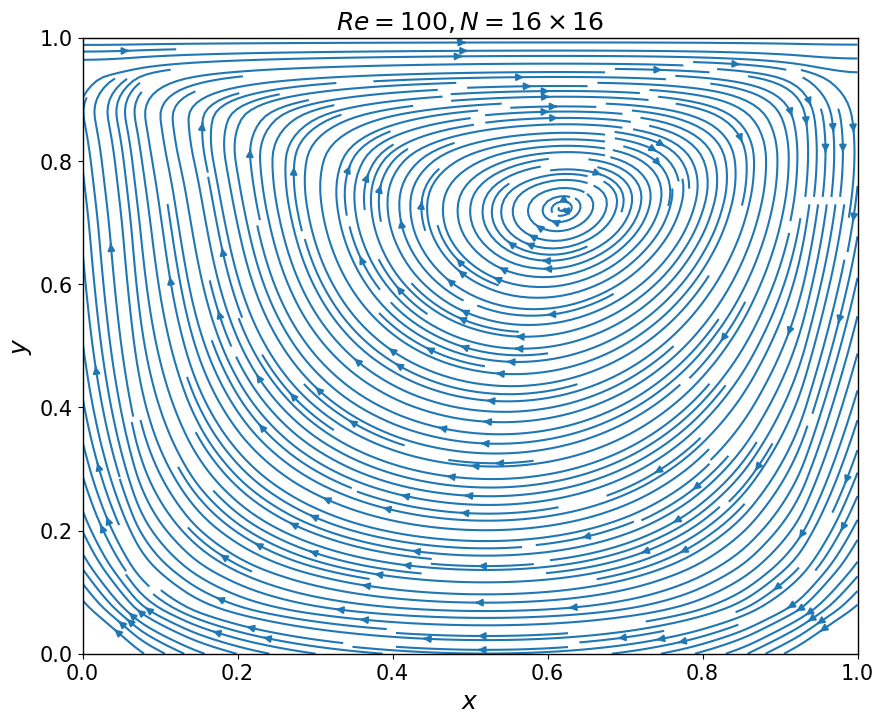

In [10]:
x = np.linspace(0,1,Nx+1)[:,None]
y = np.linspace(0,1,Ny+1)[:,None]
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(10, 8))
plt.streamplot(X,Y,Psi_qlbm1[t,:,:].T,Psi_qlbm2[t,:,:].T,density=3)
plt.tick_params(labelsize=15)
plt.xlim(0.0,1.0)
plt.xlabel('$x$', size = 18)
plt.ylabel('$y$', size = 18)
plt.title(r"$Re=100,N = 16 \times 16$", size = 18)
plt.ylim(0.0,1.0)
fig1=plt.gcf()
ax=plt.gca()
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
#plt.savefig('streamline_quantum.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

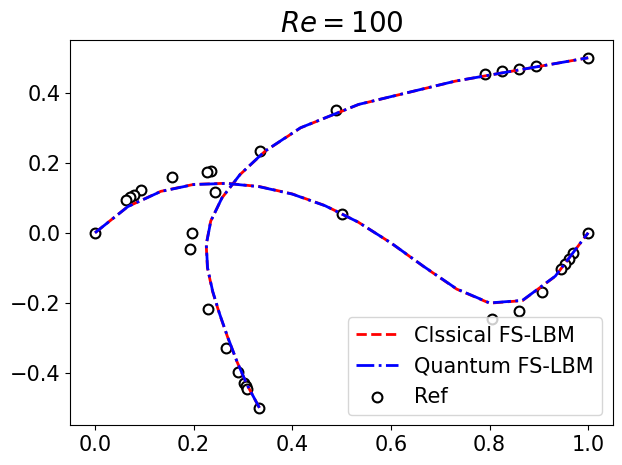

In [12]:
fig = plt.figure(figsize=(7, 5))
#plt.xlabel('$x$', size=20)
#plt.ylabel('$y$', size=20)
plt.title('$Re=100$', size=20)
#plt.xticks([0.0,0.5,1.0,1.5,2.0],(["$x=0.25$","$x=0.50$","$x=0.75$","",""]))
plt.tick_params(labelsize=15)
#plt.xlim(0.0,1.0)


#plt.xlim(0.0,1.0)
#plt.ylim(-0.7,1.1)
x_1 = np.linspace(0,1,Nx+1)
#plt.plot(x_1,10*u1[49,:,0],'k-',label='Ref',linewidth = 2,)
#plt.legend(loc=0,ncol=1,fontsize=15)
#plt.plot(x_1,10*u1[:,49,1],'k-',linewidth = 2,)

plt.plot((5*(u[int((Nx+1)/2)-1,:,0]+u[int((Nx+1)/2),:,0])+0.5)/3*2,x_1-0.5,'r--',label='Clssical FS-LBM',linewidth = 2,)
plt.plot((5*(Psi_qlbm1[t,int((Nx+1)/2)-1,:]+Psi_qlbm1[t,int((Nx+1)/2),:])+0.5)/3*2,x_1-0.5,'b-.',label='Quantum FS-LBM',linewidth = 2,)

plt.plot(x_1,5*(u[:,int((Nx+1)/2)-1,1]+u[:,int((Nx+1)/2),1]),'r--',linewidth = 2,)
plt.plot(x_1,5*(Psi_qlbm2[t,:,int((Nx+1)/2)-1]+Psi_qlbm2[t,:,int((Nx+1)/2)]),'b-.',linewidth = 2,)

##Re = 100
L1 = np.array([1.0, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641, -0.20581, -0.2109, -0.15662, -0.1015, -0.06434, -0.04775, -0.04192, -0.03717, 0.0])
L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
L4 = np.array([0.0,-0.05906,-0.07391,-0.08864,-0.10313,-0.16914,-0.22445,-0.24533,0.05454,0.17527,0.17507,0.16077,0.12317,0.1089,0.10091,0.09233,0.0])
##Re = 400
#L1 = np.array([1.0, 0.75837, 0.68439, 0.61756, 0.55892, 0.29093, 0.16256, 0.02135, -0.11477, -0.17119, -0.32726, -0.24299, -0.14612, -0.10338, -0.09266, -0.08186, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.12146,-0.15663,-0.19254,-0.22847,-0.35827,-0.43993,-0.38598,0.05186,0.30174,0.30203,0.28124,0.22965,0.20920,0.19713,0.18360,0.0])
##Re = 1000
#L1 = np.array([1.0, 0.65928, 0.57492, 0.51117, 0.46604, 0.33304, 0.18719, 0.05702, -0.0608, -0.10648, -0.27805, -0.38289, -0.2973, -0.2222, -0.20196, -0.18109, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.21388,-0.27669,-0.33714,-0.39188,-0.5155,-0.42665,-0.31966,0.02526,0.32235,0.33075,0.37095,0.32627,0.30353,0.29012,0.27485,0.0])
##Re = 5000
#L1 = np.array([1.0, 0.48223, 0.46120, 0.45992, 0.46036, 0.33556, 0.20087, 0.08183, -0.03039, -0.07404, -0.22855, -0.33050, -0.40435, -0.43643, -0.42901, -0.41165, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.49774,-0.55069,-0.55408,-0.52876,-0.41442,-0.36214,-0.30018,0.00945,0.27280,0.28066,0.35368,0.42951,0.43648,0.43329,0.42447,0.0])
##Re = 3200
#L1 = np.array([1.0, 0.53236, 0.48296, 0.46547, 0.46101, 0.34682, 0.19791, 0.07156, -0.04272, -0.086636, -0.24427, -0.34323, -0.41933, -0.37827, -0.35344, -0.32407, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.39017,-0.47425,-0.52357,-0.54053,-0.44307,-0.37401,-0.31184,0.00999,0.28188,0.29030,0.37119,0.42768,0.41906,0.40917,0.39560,0.0])
#plt.scatter(L2, L1, c='',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False)
plt.scatter(L3, L4, c='w',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False,label='Ref')
plt.scatter((L1+0.5)/3*2, L2-0.5, c='w',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False)
plt.legend(loc=0,ncol=1,fontsize=15)
#plt.scatter(L4, L3, c='',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False)
#plt.savefig('Re_100_16.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

In [13]:
# Lattice parameters for D2Q9
LATTICE_VELOCITIES = np.array([
    [ 0,  1,  0, -1,  0,  1, -1, -1,  1],
    [ 0,  0,  1,  0, -1,  1,  1, -1, -1]
])

LATTICE_WEIGHTS = np.array([
    4/9,                        # Center Velocity
    1/9, 1/9, 1/9, 1/9,         # Axis-Aligned Velocities
    1/36, 1/36, 1/36, 1/36      # Diagonal Velocities
])

# Initialize the scalar field for classical LBM
Psi_classical = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_classical[0, :, :] = Psi_init

# Speed of sound
c_s = 1 / np.sqrt(3)

# Classical LBM loop
for t in range(TIMESTEPS):
    # Calculate equilibrium distribution functions for each velocity direction
    f0 = LATTICE_WEIGHTS[0] * Psi_classical[t, :, :]
    
    f = [f0]  # List to hold all f components including f0 for easy summing later
    for i in range(1, 9):
        velocity_projection = (LATTICE_VELOCITIES[0, i] * u + LATTICE_VELOCITIES[1, i] * v) / (c_s**2)
        fi = LATTICE_WEIGHTS[i] * Psi_classical[t, :, :] * (1 + velocity_projection)
        f.append(fi)

    # Streaming step: Shift each distribution along its corresponding velocity direction
    for i in range(1, 9):
        f[i] = np.roll(np.roll(f[i], LATTICE_VELOCITIES[1, i], axis=1), LATTICE_VELOCITIES[0, i], axis=0)

    # Update scalar field by summing over all distributions
    Psi_classical[t + 1, :, :] = sum(f)

In [14]:
# Initialize MSE and RMSE arrays
MSE_opt = np.zeros(TIMESTEPS)
RMSE_opt = np.zeros(TIMESTEPS)

# Remove initial state from classical and quantum fields
Psi_classical_no_init = Psi_classical[1:, :, :]
Psi_quantum_no_init = Psi_qlbm[1:, :, :]

# Calculate MSE and RMSE for each timestep
for t in range(TIMESTEPS):
    difference = Psi_quantum_no_init[t, :, :] - Psi_classical_no_init[t, :, :]
    MSE_opt[t] = np.mean(np.square(difference))
    RMSE_opt[t] = np.sqrt(MSE_opt[t])

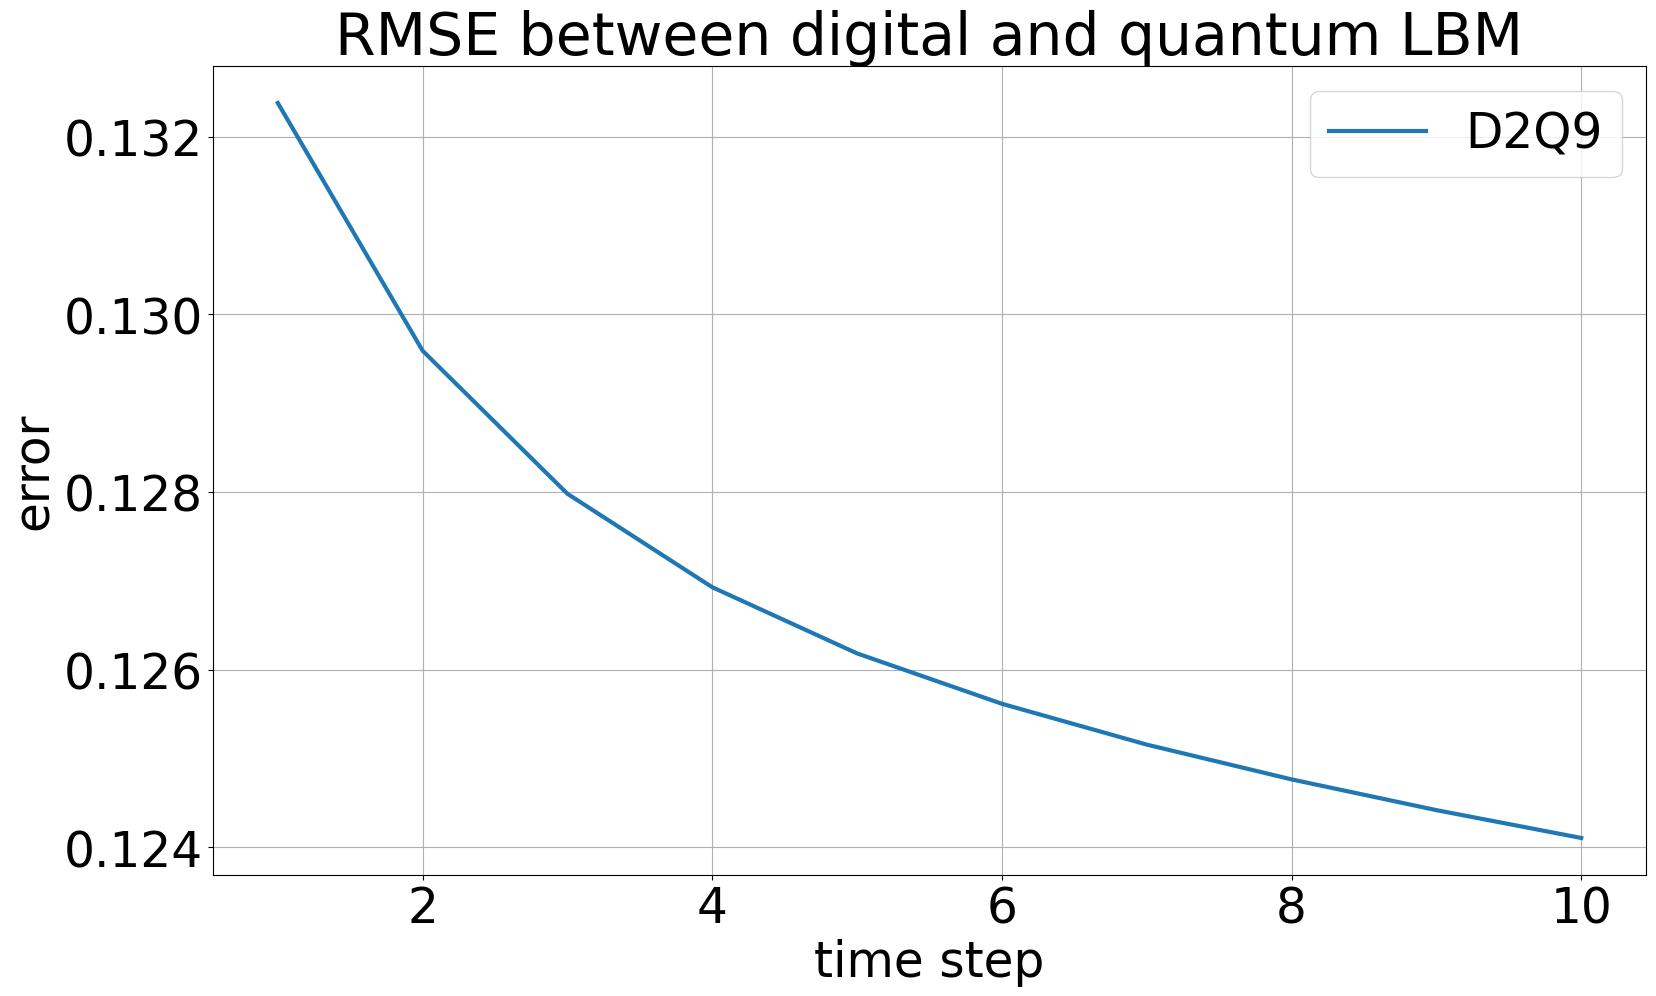

In [16]:
plt.rcParams.update({'font.size': 35})
plt.rcParams['text.usetex'] = False
plt.figure(1,figsize=(18.5, 10.5), dpi=100)
plt.plot(list(range(1, TIMESTEPS+1)),RMSE_opt, linewidth=3)
plt.grid()
plt.legend(['D2Q9'],loc=0)
plt.title('RMSE between digital and quantum LBM')
plt.ylabel('error')
plt.xlabel('time step')
plt.draw()